# Upstream tutorial: bulk ATAC-seq

This notebook is an `epione`-native rewrite of the Galaxy Training Network ATAC-seq lesson. The biological aim is the same as in the GTN tutorial: start from paired-end ATAC FASTQs, align them to a reference genome, generate signal tracks, call peaks, and inspect whether the resulting data show the expected structure around a representative genomic locus and around transcription start sites.

What changes here is the execution model. Galaxy teaches the workflow as a sequence of web tools and dataset collections, whereas this notebook teaches the same logic through `epi.upstream.*` functions. The notebook is therefore meant to serve two roles at once:

| Role | What it gives you |
| --- | --- |
| **Executable tutorial** | A small, public, end-to-end example that runs locally in the `omicdev` environment. |
| **Project template** | A direct prototype for replacing the toy FASTQs with real OTX2 samples while keeping the same `epione` API. |

The underlying teaching dataset is the downsampled GTN ATAC example enriched for `chr22`. To keep the notebook genuinely runnable, we also build a lightweight `chr22` demo reference from a locally cached GRCh38 FASTA. That makes the example much smaller than a full human run, but still preserves the same upstream concepts: alignment, filtering, fragment generation, Tn5 shifting, coverage export, peak calling, browser-style visualisation, and TSS-centred signal summarisation.


> **Scope note.** This notebook covers the *upstream* part of a bulk ATAC-seq workflow: `FASTQ -> filtered BAM -> fragments -> shifted BAM -> bigWig -> peaks -> visual QC`. It does **not** cover downstream differential accessibility, motif analysis, or integration with RNA-seq.

### Data provenance

The example FASTQs are the public teaching files from the Galaxy Training Network ATAC-seq tutorial. In the GTN lesson they are used to demonstrate end-to-end preprocessing on a compact dataset that can be inspected interactively.

For this notebook we keep the same teaching logic but change the interface:

| Item | Source | How it is used here |
| --- | --- | --- |
| **Paired-end FASTQs** | Galaxy GTN ATAC tutorial toy dataset | Demonstrates the full upstream pipeline from alignment to peak calling. |
| **GRCh38 FASTA** | Local cache on this machine | Used to derive a small `chr22` reference so the notebook remains executable. |
| **Galaxy locus** | The `RAC2 / SSTR3` region shown in the GTN tutorial | Reused for locus-level visualization with `epi.bulk.bigwig`. |

Local paths used throughout the notebook:

```text
case/otx2/galaxy_atac_demo/
  fastq/     # downloaded GTN toy FASTQs
  ref/       # chr22 FASTA + bowtie2 index + derived annotation
  result/    # BAMs, fragments, bigWigs, MACS2 peaks
```

### Learning goals

By the end of the notebook, you should be able to answer five practical questions:

1. What is the minimal set of tools an `epione` ATAC-seq upstream run depends on?
2. How do `epi.upstream.bowtie2.align_fastq_to_bam`, `epi.upstream.samtools.filter_bam`, and `epi.upstream.pipeline.bam_to_frags` define the generic `FASTQ -> BAM -> fragments` backbone?
3. Why does ATAC-seq add an explicit `epi.upstream.atac.shift_atac_bam` step before coverage export?
4. How do we turn a processed ATAC BAM into interpretable peak and bigWig outputs?
5. How can the same explicit `epione.upstream` steps be transferred from a toy teaching example to real OTX2 samples?


In [1]:
import os
import pathlib
import urllib.request
import warnings

import pandas as pd
import epione as epi

warnings.filterwarnings('ignore', message='Function .* is missing a docstring.*')
os.environ['LC_ALL'] = 'C'
os.environ['LC_CTYPE'] = 'C'

epi.pl.plot_set()

WORK = pathlib.Path.cwd()
DATA = WORK / 'galaxy_atac_demo'
FASTQ_DIR = DATA / 'fastq'
REF_DIR = DATA / 'ref'
OUT = DATA / 'result'
for p in [FASTQ_DIR, REF_DIR, OUT]:
    p.mkdir(parents=True, exist_ok=True)

# Reuse the locally cached GRCh38 FASTA, but build a chr22-only demo reference
# so the tutorial remains lightweight enough to execute end-to-end.
HG38_FASTA = pathlib.Path('/scratch/users/steorra/data/snapatac2_cache/gencode_v41_GRCh38.fa.gz.decomp')
CHR22_FASTA = REF_DIR / 'chr22.fa'
CHR22_BT2_PREFIX = REF_DIR / 'chr22'
CHR22_SIZE = 50818468

ATAC_URLS = {
    'SRR891268_chr22_enriched_R1.fastq.gz': 'https://zenodo.org/record/3862793/files/SRR891268_chr22_enriched_R1.fastq.gz',
    'SRR891268_chr22_enriched_R2.fastq.gz': 'https://zenodo.org/record/3862793/files/SRR891268_chr22_enriched_R2.fastq.gz',
}


└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## 1. Check upstream tools

The Galaxy tutorial distributes preprocessing across several web tools, which makes it easy to forget that an ATAC-seq upstream workflow still depends on a fairly standard command-line stack under the hood. Before we touch the reads, we therefore make the dependency surface explicit.

For this notebook the critical components are:

| Tool family | Why it matters |
| --- | --- |
| `bowtie2` | Aligns the paired-end ATAC reads to the reference genome. |
| `samtools` | Sorts, filters, and indexes BAM files. |
| `bedtools` | Supports fragment and interval-style conversions. |
| `MACS2` | Calls open chromatin peaks from the shifted ATAC alignments. |
| `epione` built-in implementations | Default Tn5 shifting and bigWig generation used directly inside the Python workflow. |

`epione` wraps these tools, but it does not make their role disappear. Running a concise dependency check up front makes the notebook easier to debug and also mirrors good project hygiene: if the environment is inconsistent, it is better to learn that in seconds rather than after alignment has already run for several minutes.


In [2]:
epi.upstream.check_tools([
    'bowtie2',
    'samtools',
    'bedtools',
    'macs2',
])


  ✓  bowtie2                    /scratch/users/steorra/env/omicdev/bin/bowtie2
  ✓  samtools                   /scratch/users/steorra/env/omicdev/bin/samtools
  ✓  bedtools                   /scratch/users/steorra/env/omicdev/bin/bedtools
  ✓  macs2                      /scratch/users/steorra/env/omicdev/bin/macs2


{'bowtie2': '/scratch/users/steorra/env/omicdev/bin/bowtie2',
 'samtools': '/scratch/users/steorra/env/omicdev/bin/samtools',
 'bedtools': '/scratch/users/steorra/env/omicdev/bin/bedtools',
 'macs2': '/scratch/users/steorra/env/omicdev/bin/macs2'}

## 2. Download the Galaxy toy FASTQs

The input files are the small paired-end FASTQs distributed with the Galaxy GTN ATAC-seq tutorial. They are downsampled and focused enough to support a complete teaching run while still containing the core structure of a real ATAC dataset.

Why use the Galaxy files instead of an arbitrary demo pair?

- They are already tied to a published teaching narrative.
- They are small enough to run repeatedly in a notebook.
- They support a known locus-level example on `chr22`.
- They make it easier to compare the `epione` output with the logic of the original GTN lesson.

At this stage we are only establishing the raw inputs. The important check is simply that the expected `R1` and `R2` files exist on disk and can now be passed to `epi.upstream.*` functions without any manual dataset bookkeeping.


In [3]:
for name, url in ATAC_URLS.items():
    out = FASTQ_DIR / name
    if not out.exists():
        print(f'downloading {name} ...')
        urllib.request.urlretrieve(url, out)
    else:
        print(f'skip existing: {name}')

fq1 = FASTQ_DIR / 'SRR891268_chr22_enriched_R1.fastq.gz'
fq2 = FASTQ_DIR / 'SRR891268_chr22_enriched_R2.fastq.gz'
pd.DataFrame({'fq1': [str(fq1)], 'fq2': [str(fq2)]})


downloading SRR891268_chr22_enriched_R1.fastq.gz ...


downloading SRR891268_chr22_enriched_R2.fastq.gz ...


,fq1,fq2
0,/scratch/users/steorra/analysis/omicverse_dev/...,/scratch/users/steorra/analysis/omicverse_dev/...


## 3. Prepare a `chr22` demo reference

The original Galaxy tutorial is framed as a human-genome ATAC workflow, but the teaching plots focus on a chromosome 22 locus. For a notebook that must be executable from start to finish, building a full human bowtie2 index would be unnecessary overhead. We therefore construct a compact teaching reference containing only `chr22`.

This is a deliberate distinction between **tutorial engineering** and **biological best practice**:

| Scenario | Recommended reference |
| --- | --- |
| **Notebook demo / teaching run** | A reduced `chr22` reference to keep runtime and disk use small. |
| **Real project analysis** | A full genome index matching the species, assembly, and annotation used in the study. |

The `epi.upstream.prepare_reference` call encapsulates the reference-preparation step that is often scattered across shell scripts. Its main job is to ensure that the FASTA, chromosome sizes, and aligner index are all present in a form the later upstream functions can consume directly.


In [4]:
%%time
from pyfaidx import Fasta

if not CHR22_FASTA.exists():
    fa = Fasta(str(HG38_FASTA))
    with open(CHR22_FASTA, 'w') as fout:
        fout.write('>chr22\n')
        seq = str(fa['chr22'])
        for i in range(0, len(seq), 60):
            fout.write(seq[i:i+60] + '\n')

ref = epi.upstream.prepare_reference(
    fasta=CHR22_FASTA,
    aligner='bowtie2',
    index_prefix=CHR22_BT2_PREFIX,
)
ref


Settings:
  Output files: "/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.*.bt2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Max bucket size: default
  Max bucket size, sqrt multiplier: default
  Max bucket size, len divisor: 4
  Difference-cover sample period: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.fa
Reading reference sizes


Building a SMALL index


  Time reading reference sizes: 00:00:00
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:00
bmax according to bmaxDivN setting: 9789944
Using parameters --bmax 7342458 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these parameters: --bmax 7342458 --dcv 1024
Constructing suffix-array element generator
Building DifferenceCoverSample
  Building sPrime
  Building sPrimeOrder
  V-Sorting samples


  V-Sorting samples time: 00:00:00
  Allocating rank array
  Ranking v-sort output
  Ranking v-sort output time: 00:00:01
  Invoking Larsson-Sadakane on ranks


  Invoking Larsson-Sadakane on ranks time: 00:00:00
  Sanity-checking and returning
Building samples
Reserving space for 12 sample suffixes
Generating random suffixes
QSorting 12 sample offsets, eliminating duplicates
QSorting sample offsets, eliminating duplicates time: 00:00:00
Multikey QSorting 12 samples
  (Using difference cover)
  Multikey QSorting samples time: 00:00:00
Calculating bucket sizes


...

Getting block 7 of 7
  Reserving size (7342458) for bucket 7
  Calculating Z arrays for bucket 7
  Entering block accumulator loop for bucket 7:
  bucket 7: 10%
  bucket 7: 20%
  bucket 7: 30%
  bucket 7: 40%
  bucket 7: 50%
  bucket 7: 60%


  bucket 7: 70%
  bucket 7: 80%
  bucket 7: 90%
  bucket 7: 100%
  Sorting block of length 3942565 for bucket 7
  (Using difference cover)


  Sorting block time: 00:00:01
Returning block of 3942566 for bucket 7
Exited Ebwt loop
fchr[A]: 0
fchr[C]: 10382214
fchr[G]: 19542866
fchr[T]: 28789052
fchr[$]: 39159777
Exiting Ebwt::buildToDisk()
Returning from initFromVector
Wrote 17248347 bytes to primary EBWT file: /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.rev.1.bt2.tmp
Wrote 9789952 bytes to secondary EBWT file: /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.rev.2.bt2.tmp
Re-opening _in1 and _in2 as input streams
Returning from Ebwt constructor
Headers:
    len: 39159777
    bwtLen: 39159778
    sz: 9789945
    bwtSz: 9789945
    lineRate: 6
    offRate: 4
    offMask: 0xfffffff0
    ftabChars: 10
    eftabLen: 20
    eftabSz: 80
    ftabLen: 1048577
    ftabSz: 4194308
    offsLen: 2447487
    offsSz: 9789948
    lineSz: 64
    sideSz: 64
    sideBwtSz: 48
    sideBwtLen: 192
    numSides: 203958
    nu

Renaming /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.3.bt2.tmp to /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.3.bt2
Renaming /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.4.bt2.tmp to /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.4.bt2
Renaming /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.1.bt2.tmp to /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.1.bt2
Renaming /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.2.bt2.tmp to /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.2.bt2
Renaming /scratch/users/

{'fasta': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.fa',
 'fai': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.fa.fai',
 'chrom_sizes': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22.chrom.sizes',
 'ref_index': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/chr22'}

## 4. Build the generic paired-end backbone explicitly

Instead of calling a single convenience wrapper, this notebook now spells out the reusable upstream backbone as separate `epione.upstream` operations. That makes the control points obvious:

1. `epi.upstream.bowtie2.align_fastq_to_bam(...)` performs the raw paired-end alignment and duplicate marking.
2. `epi.upstream.samtools.filter_bam(...)` applies the mapping-quality and flag filters that define the retained alignment set.
3. `epi.upstream.samtools.index_bam(...)` creates the BAM index needed for downstream random access.
4. `epi.upstream.pipeline.bam_to_frags(...)` converts the filtered paired-end BAM into a fragment table.

This decomposition is closer to how the workflow is reasoned about biologically. The fragment file is no longer a side effect of a wrapper. It is an explicit output produced from an explicit filtered BAM.

### Why keep the fragment file?

Even though the rest of the tutorial emphasizes signal tracks and peak calling, the fragment table remains valuable because it captures the retained paired-end molecules directly and can be reused in later accessibility analyses.


In [5]:
%%time
sample_name = 'SRR891268_galaxy_atac'
frag_dir = OUT / 'fragments'
frag_dir.mkdir(parents=True, exist_ok=True)
raw_bam = frag_dir / f'{sample_name}.raw.bam'
filt_bam = frag_dir / f'{sample_name}.filtered.bam'
frags_path = frag_dir / f'{sample_name}.frags.tsv.gz'

for stale in [raw_bam, filt_bam, pathlib.Path(str(filt_bam) + '.bai'), frags_path]:
    if stale.exists():
        stale.unlink()

epi.upstream.bowtie2.align_fastq_to_bam(
    fq1=str(fq1),
    fq2=str(fq2),
    out_bam=raw_bam,
    ref_index=ref['ref_index'],
    threads=8,
    extra_args=['--very-sensitive', '-X', '2000'],
    remove_duplicates=True,
)
epi.upstream.samtools.filter_bam(
    raw_bam,
    filt_bam,
    mapq=30,
    proper_pair=True,
    drop_secondary_supp=True,
    drop_duplicates=False,
    drop_qcfail=True,
    drop_unmapped=True,
    drop_mate_unmapped=True,
    drop_chroms=('chrM',),
    threads=8,
)
epi.upstream.samtools.index_bam(filt_bam, threads=8)
epi.upstream.pipeline.bam_to_frags(filt_bam, sample_name, frags_path)
raw_bam.unlink(missing_ok=True)

bam_path = str(filt_bam)
frags_path = str(frags_path)
{'bam': bam_path, 'frags': frags_path}


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


285247 reads; of these:
  285247 (100.00%) were paired; of these:
    208104 (72.96%) aligned concordantly 0 times
    58889 (20.64%) aligned concordantly exactly 1 time
    18254 (6.40%) aligned concordantly >1 times
    ----
    208104 pairs aligned concordantly 0 times; of these:
      5353 (2.57%) aligned discordantly 1 time
    ----
    202751 pairs aligned 0 times concordantly or discordantly; of these:
      405502 mates make up the pairs; of these:
        389954 (96.17%) aligned 0 times
        4843 (1.19%) aligned exactly 1 time
        10705 (2.64%) aligned >1 times
31.65% overall alignment rate


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 64 in-memory blocks...


CPU times: user 2.97 ms, sys: 35.4 ms, total: 38.3 ms
Wall time: 16.1 s


{'bam': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/fragments/SRR891268_galaxy_atac.filtered.bam',
 'frags': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/fragments/SRR891268_galaxy_atac.frags.tsv.gz'}

## 5. Add the ATAC-specific processing steps explicitly

The generic backbone above gives us a filtered paired-end BAM and a fragment table. ATAC-seq then adds one assay-specific transformation before browser-style visualization: Tn5 shifting.

Here the assay logic is again written as separate steps rather than hidden inside a high-level helper:

| Operation | `epione` function | Why it matters |
| --- | --- | --- |
| **Tn5 offset correction** | `epi.upstream.atac.shift_atac_bam(...)` | Moves aligned ends closer to the transposition event. |
| **Coverage export** | `epi.upstream.bigwig.bam_to_bigwig(...)` | Converts the shifted BAM into a signal track for plotting and matrix aggregation. |

This layout makes the ATAC-specific part of the pipeline very clear: ATAC is just the generic paired-end backbone plus the shift step plus coverage export.


In [6]:
%%time
atac_dir = OUT / 'atac'
atac_dir.mkdir(parents=True, exist_ok=True)
shift_bam = atac_dir / f'{sample_name}.shift.bam'
atac_bw = atac_dir / f'{sample_name}.bw'
source_bam = OUT / 'fragments' / f'{sample_name}.filtered.bam'

for stale in [shift_bam, pathlib.Path(str(shift_bam) + '.bai'), atac_bw]:
    if stale.exists():
        stale.unlink()

epi.upstream.atac.shift_atac_bam(
    source_bam,
    shift_bam,
    threads=8,
    index=True,
)
epi.upstream.bigwig.bam_to_bigwig(
    shift_bam,
    atac_bw,
    bin_size=10,
    threads=8,
)

{
    'shift_bam': str(shift_bam),
    'bigwig': str(atac_bw),
}


CPU times: user 26.4 s, sys: 625 ms, total: 27.1 s
Wall time: 26.4 s


{'shift_bam': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/atac/SRR891268_galaxy_atac.shift.bam',
 'bigwig': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/atac/SRR891268_galaxy_atac.bw'}

## 6. Peak calling

Once the shifted ATAC BAM is available, the next goal is to identify candidate accessible regions. In practical terms, this means converting the processed alignment into a standard peak set that can later be visualized, annotated, intersected with motifs, or compared across samples.

### Why peak calling is still a separate step

Coverage tracks are useful for visual interpretation, but they are not an analysis-ready set of regions. Peak calling imposes a statistical threshold and converts a continuous signal profile into a discrete list of candidate regulatory intervals.

### The function

`epi.upstream.macs2.call_peaks_macs2(...)` is the `epione` wrapper around MACS2 peak calling.

| Key parameter | What it controls |
| --- | --- |
| `bam` | Input alignment used as the signal source. |
| `format='BAMPE'` | Treats the data as paired-end fragments rather than single-end reads. |
| `qvalue` | Reporting threshold for significant peaks. |
| `nomodel=True` | Skips model building, which is common for ATAC-seq workflows. |

Because the executable notebook runs on a reduced `chr22` reference, the goal is not to estimate a publication-ready regulatory catalogue. The goal is to produce a coherent toy peak set that can be interrogated visually.


In [7]:
%%time
sample_name = 'SRR891268_galaxy_atac'
shift_bam = OUT / 'atac' / f'{sample_name}.shift.bam'
if not shift_bam.exists():
    epi.upstream.atac.shift_atac_bam(
        OUT / 'fragments' / f'{sample_name}.filtered.bam',
        shift_bam,
        threads=8,
        index=True,
    )
peak_paths = epi.upstream.macs2.call_peaks_macs2(
    bam=shift_bam,
    out_dir=OUT / 'peaks',
    name=sample_name,
    genome_size='hs',
    format='BAMPE',
    qvalue=0.01,
    keep_dup='all',
    call_summits=True,
    nomodel=True,
)
peak_paths


INFO  @ Sat, 25 Apr 2026 14:39:10: 
# Command line: callpeak -t /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/atac/SRR891268_galaxy_atac.shift.bam -f BAMPE -g hs --keep-dup all -q 0.01 -n SRR891268_galaxy_atac --outdir /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks --nomodel --call-summits
# ARGUMENTS LIST:
# name = SRR891268_galaxy_atac
# format = BAMPE
# ChIP-seq file = ['/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/atac/SRR891268_galaxy_atac.shift.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 1.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range 

CPU times: user 1.79 ms, sys: 1.04 ms, total: 2.83 ms
Wall time: 484 ms


INFO  @ Sat, 25 Apr 2026 14:39:10: #3 Call peaks for each chromosome... 
INFO  @ Sat, 25 Apr 2026 14:39:10: #4 Write output xls file... /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks/SRR891268_galaxy_atac_peaks.xls 
INFO  @ Sat, 25 Apr 2026 14:39:10: #4 Write peak in narrowPeak format file... /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks/SRR891268_galaxy_atac_peaks.narrowPeak 
INFO  @ Sat, 25 Apr 2026 14:39:10: #4 Write summits bed file... /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks/SRR891268_galaxy_atac_summits.bed 
INFO  @ Sat, 25 Apr 2026 14:39:10: Done! 


{'narrowPeak': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks/SRR891268_galaxy_atac_peaks.narrowPeak',
 'summits': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks/SRR891268_galaxy_atac_summits.bed',
 'xls': '/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/result/peaks/SRR891268_galaxy_atac_peaks.xls'}

### Reading the peak output

After MACS2 finishes, the result directory contains several standard files. The exact filenames are not the main lesson; the important point is what they *mean*:

| File type | Interpretation |
| --- | --- |
| `*_peaks.narrowPeak` | Main interval set used for plotting and downstream analysis. |
| `*_summits.bed` | Local maxima within broader peak intervals. |
| `*_peaks.xls` | Verbose MACS2 report with scores and supporting statistics. |

In a full project run you would now typically inspect peak counts, overlap with promoters or distal elements, and reproducibility across replicates. In this compact tutorial we instead carry the resulting peak intervals forward into a locus-level visualization step.


## 7. Visualise the Galaxy locus with `epi.bulk.bigwig`

One of the strengths of the Galaxy ATAC tutorial is that it does not stop at file generation. It also shows how to *read* the output by looking at an instructive genomic locus. We keep exactly that teaching move here and reuse the same `chr22:37,193,000-37,252,000` region near `RAC2 / SSTR3`.

### Biological question

Does the processed ATAC signal produce a coherent accessibility profile at this locus, and do the called peaks align with the strongest local enrichments in the bigWig track?

### The function

`epi.bulk.bigwig(...).plot_track(...)` renders browser-style signal tracks directly from bigWig files.

| Key parameter | What it controls |
| --- | --- |
| `chrom`, `chromstart`, `chromend` | Genomic window shown in the plot. |
| `plot_names` | Which registered bigWig tracks to display. |
| `bp_per_bin` | Horizontal aggregation scale in base pairs. |
| `region_dict` | Highlight boxes marking intervals of special interest, here the MACS2 peaks. |
| `color_dict` | Per-track visual color mapping. |

### How to read the plot

A useful browser panel should show agreement between the two representations of the data:

- the **continuous** signal profile in the bigWig track, and
- the **discrete** intervals in the peak set.

If the strongest called peaks sit on top of the strongest local coverage enrichments, the preprocessing chain has produced an internally consistent result.


└─ Load bigWig files
  └─ Loading ATAC...


(<Figure size 640x144 with 1 Axes>, [<Axes: ylabel='ATAC'>])

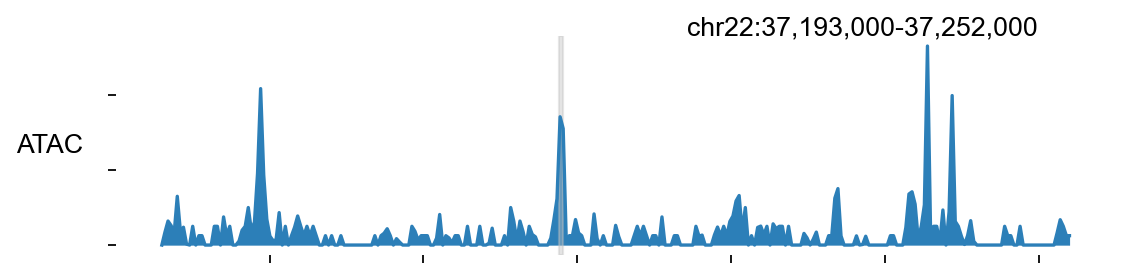

In [8]:
ATAC_GALAXY_LOCUS = ('chr22', 37193000, 37252000)
atac_bigwig = str(OUT / 'atac' / 'SRR891268_galaxy_atac.bw')

bw_obj = epi.bulk.bigwig({'ATAC': atac_bigwig})
bw_obj.read()

peak_df = pd.read_csv(peak_paths['narrowPeak'], sep='	', header=None)
peak_df = peak_df[peak_df[0] == 'chr22'].copy()
peak_df = peak_df[(peak_df[1] < ATAC_GALAXY_LOCUS[2]) & (peak_df[2] > ATAC_GALAXY_LOCUS[1])]
region_dict = {
    f'peak_{i+1}': (int(r[1]), int(r[2]))
    for i, r in peak_df.head(8).iterrows()
}
color_dict = {'ATAC': '#2C7FB8'}

bw_obj.plot_track(
    chrom=ATAC_GALAXY_LOCUS[0],
    chromstart=ATAC_GALAXY_LOCUS[1],
    chromend=ATAC_GALAXY_LOCUS[2],
    plot_names=['ATAC'],
    figwidth=8,
    figheight=1.8,
    color_dict=color_dict,
    bp_per_bin=200,
    region_dict=region_dict,
)


## 8. Compute a TSS heatmap with `epi.bulk.bigwig`

A locus snapshot is informative, but it is still a hand-picked view. To complement that local visualization, we also compute a TSS-centered heatmap and mean profile. This mirrors the signal-aggregation logic commonly taught in browser- or matrix-based genomics tutorials, but uses `epione.bulk.bigwig` directly.

### Biological question

Is accessibility enriched around transcription start sites in the processed ATAC bigWig, as we would expect for a plausible ATAC-seq dataset?

### Why a temporary `chr22` annotation is created

The notebook runs on a reduced `chr22` reference, so we also derive a minimal transcript annotation from the local GRCh38 GENCODE `gff3` file. That small GTF is not meant to replace a proper project annotation; it is only a lightweight teaching companion that lets the matrix computation stay consistent with the reduced demo reference.

### The functions

This section follows the same three-step logic as more elaborate `epione` visualization tutorials:

1. `load_gtf(...)` to register transcript coordinates.
2. `compute_matrix(...)` to aggregate signal around TSSs.
3. `plot_matrix(...)` and `plot_matrix_line(...)` to display the heatmap and the mean profile.

| Output | What it tells you |
| --- | --- |
| **TSS heatmap** | Whether many genes show promoter-proximal enrichment rather than a flat background. |
| **Mean profile** | Whether the aggregate signal peaks around the TSS center. |

Together with the browser panel above, this gives both a *local* and a *global* quality readout for the processed ATAC demo.


In [9]:
GENCODE_GFF3 = pathlib.Path('/scratch/users/steorra/data/snapatac2_cache/gencode_v41_GRCh38.gff3.gz')
CHR22_GTF = REF_DIR / 'gencode_v41_chr22.transcripts.gtf'

CHR22_GTF = pathlib.Path(
    epi.utils.convert_gff_to_gtf(
        GENCODE_GFF3,
        CHR22_GTF,
        feature_whitelist=['transcript'],
        seqname_whitelist=['chr22'],
    )
)

with open(CHR22_GTF) as fin:
    transcript_count = sum(1 for _ in fin)

print(CHR22_GTF, transcript_count)


└─ Converting GFF to GTF: /scratch/users/steorra/data/snapatac2_cache/gencode_v41_GRCh38.gff3.gz -> /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/gencode_v41_chr22.transcripts.gtf


└─ Wrote 3939 GTF records
/scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/gencode_v41_chr22.transcripts.gtf 3939


└─ Load bigWig files
  └─ Loading ATAC...
└─ Load GTF file
  ├─ Reading GTF...
  └─ Reading GTF file from /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/bulk/galaxy_atac_demo/ref/gencode_v41_chr22.transcripts.gtf...
  └─ GTF file read successfully
  └─ GTF loaded
└─ Compute matrix: ATAC
  ├─ Prepare features
  ├─ Build matrices


Chromosomes:   0%|                                                                                                | 0/1 [00:00<?, ?chr/s]

Chromosomes: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.55chr/s]

Chromosomes: 100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.55chr/s]

  └─ Finalize
  └─ ATAC matrix finished
  └─ ATAC tss matrix in bw_tss_scores_dict[ATAC]
  └─ ATAC tes matrix in bw_tes_scores_dict[ATAC]
  └─ ATAC body matrix in bw_body_scores_dict[ATAC]


(<Figure size 256x208 with 1 Axes>, <Axes: title={'center': 'ATAC TSS mean'}>)

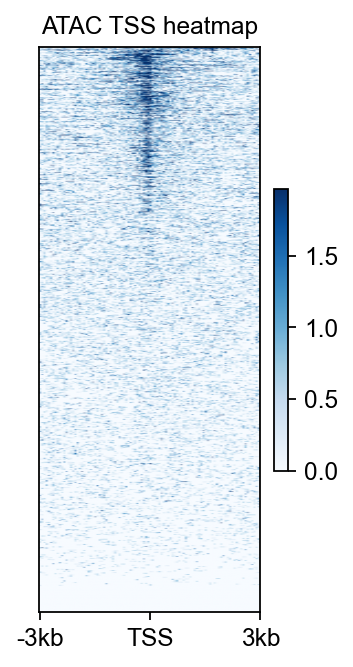

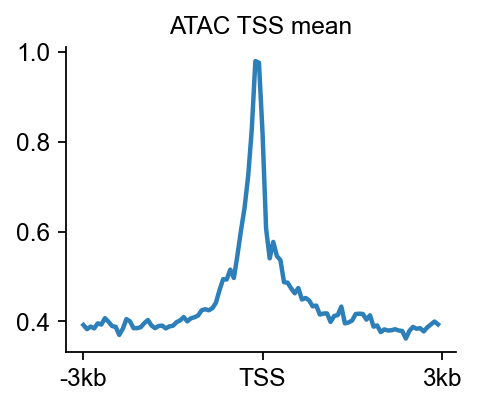

In [10]:
atac_bigwig = str(OUT / 'atac' / 'SRR891268_galaxy_atac.bw')
atac_tss = epi.bulk.bigwig({'ATAC': atac_bigwig})
atac_tss.read()
atac_tss.load_gtf(str(CHR22_GTF))
atac_tss.compute_matrix('ATAC', nbins=100, upstream=3000, downstream=3000, n_jobs=1)

fig, ax = atac_tss.plot_matrix(
    bw_name='ATAC',
    bw_type='TSS',
    figsize=(2.4, 4.2),
    cmap='Blues',
    vmax='auto',
    vmin='auto',
    fontsize=11,
    title='ATAC TSS heatmap',
)

atac_tss.plot_matrix_line(
    bw_name='ATAC',
    bw_type='TSS',
    figsize=(3.2, 2.6),
    color='#2C7FB8',
    fontsize=11,
    title='ATAC TSS mean',
)


## 9. OTX2 project template

The final code cell is intentionally not another toy-data exercise. Instead, it is the handoff from tutorial mode to project mode. Replace the GTN FASTQ paths with the real OTX2 inputs, point `ref_index` to the full production reference, and keep the same explicit sequence of `epi.upstream.bowtie2`, `epi.upstream.samtools`, `epi.upstream.atac`, `epi.upstream.bigwig`, and `epi.upstream.macs2` calls.

The important point is that there is no notebook-only wrapper hiding the workflow. The tutorial path and the project path now share the same step-by-step API surface.


In [11]:
# sample_name = 'h_OTX2_day2_ATAC'
# out_dir = WORK / 'otx2_upstream' / sample_name
# out_dir.mkdir(parents=True, exist_ok=True)
# raw_bam = out_dir / f'{sample_name}.raw.bam'
# filt_bam = out_dir / f'{sample_name}.filtered.bam'
# frags = out_dir / f'{sample_name}.frags.tsv.gz'
# shift_bam = out_dir / f'{sample_name}.shift.bam'
# bw_path = out_dir / f'{sample_name}.bw'
#
# epi.upstream.bowtie2.align_fastq_to_bam(
#     fq1='/path/to/h_OTX2_day2_ATAC_R1.fastq.gz',
#     fq2='/path/to/h_OTX2_day2_ATAC_R2.fastq.gz',
#     out_bam=raw_bam,
#     ref_index='/path/to/full/genome/index/prefix',
#     threads=8,
#     extra_args=['--very-sensitive', '-X', '2000'],
#     remove_duplicates=True,
# )
# epi.upstream.samtools.filter_bam(
#     raw_bam,
#     filt_bam,
#     mapq=30,
#     proper_pair=True,
#     drop_secondary_supp=True,
#     drop_qcfail=True,
#     drop_unmapped=True,
#     drop_mate_unmapped=True,
#     drop_chroms=('chrM',),
#     threads=8,
# )
# epi.upstream.samtools.index_bam(filt_bam, threads=8)
# epi.upstream.pipeline.bam_to_frags(filt_bam, sample_name, frags)
# epi.upstream.atac.shift_atac_bam(filt_bam, shift_bam, threads=8, index=True)
# epi.upstream.bigwig.bam_to_bigwig(shift_bam, bw_path, bin_size=10, threads=8)
# peak_paths = epi.upstream.macs2.call_peaks_macs2(
#     bam=shift_bam,
#     out_dir=WORK / 'otx2_upstream' / 'peaks',
#     name=sample_name,
#     genome_size='hs',
#     format='BAMPE',
#     qvalue=0.01,
#     keep_dup='all',
#     call_summits=True,
#     nomodel=True,
# )
